In [9]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set(style="whitegrid")

order_path = Path(r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed\olist_master_order_level.csv")
item_path = Path(r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed\olist_master_item_level.csv")

# Load datasets
orders = pd.read_csv(
    order_path,
    parse_dates=["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
)
items = pd.read_csv(item_path)

### Creating Time Features

- Cause both Q1 & Q13 require the same time columns.

In [10]:
# Year-Month & Quarter
orders["orders_year_month"] = orders["order_purchase_timestamp"].dt.to_period("M")
orders["orders_quarter"] = orders["order_purchase_timestamp"].dt.to_period("Q")
orders["order_year"] = orders["order_purchase_timestamp"].dt.year
orders["order_month"] = orders["order_purchase_timestamp"].dt.month 

#### Q1. Orders & Revenue Over Time

#### Monthly trends

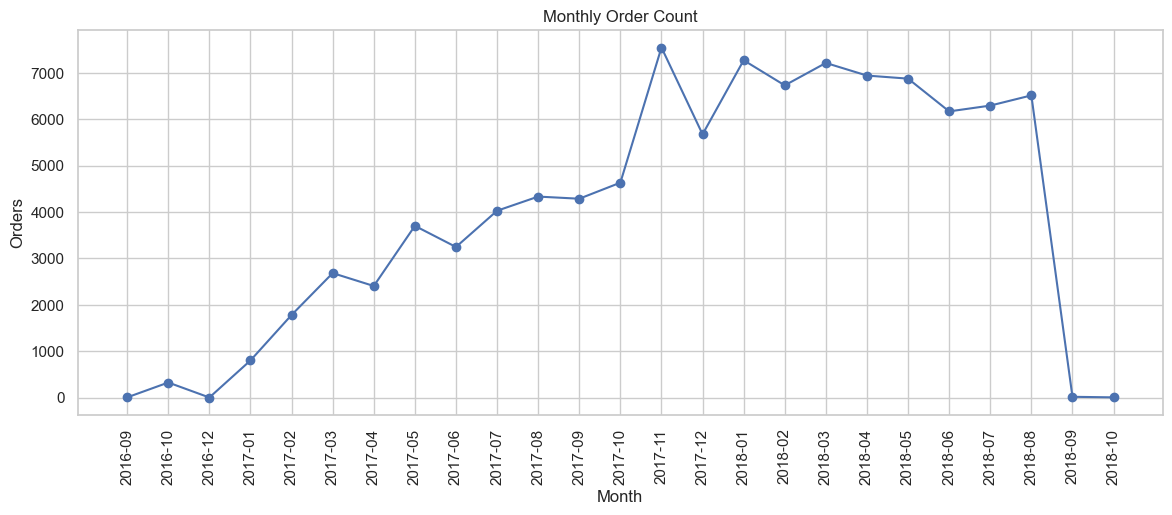

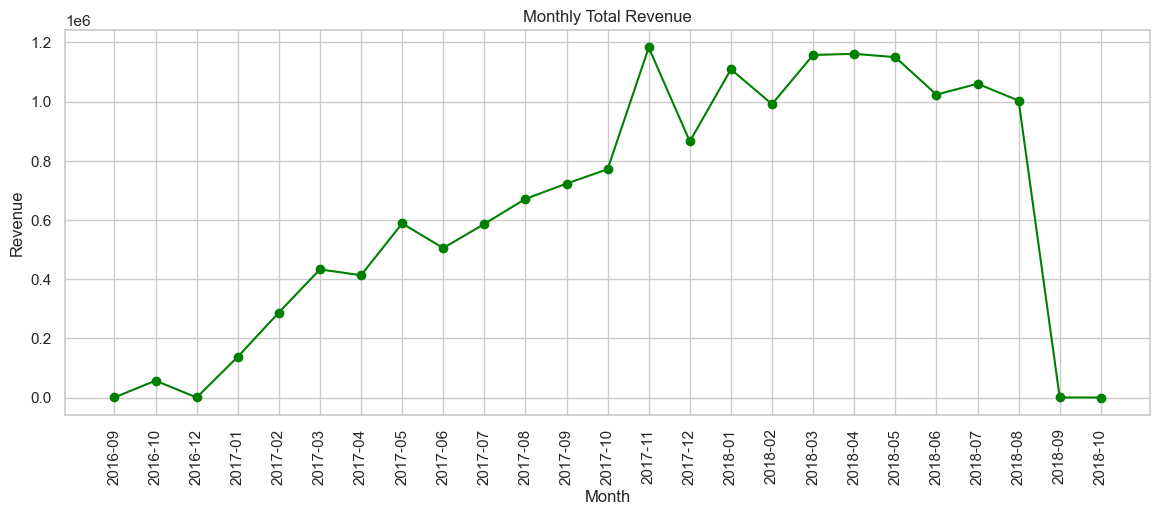

In [11]:
monthly_summary = orders.groupby('orders_year_month').agg(
    order_count=('order_id', 'count'),
    total_revenue=('total_revenue', 'sum'),
    avg_order_value=('total_revenue', 'mean')
).reset_index()

# Order per month
plt.figure(figsize=(14,5))
plt.plot(monthly_summary['orders_year_month'].astype(str), monthly_summary['order_count'], marker='o')
plt.title("Monthly Order Count")
plt.xticks(rotation=90)
plt.ylabel("Orders")
plt.xlabel("Month")
plt.show()

#Revenu per month
plt.figure(figsize=(14,5))
plt.plot(monthly_summary['orders_year_month'].astype(str), monthly_summary['total_revenue'], marker='o', color='green')
plt.title("Monthly Total Revenue")
plt.xticks(rotation=90)
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.show()


#### Quarterly trends

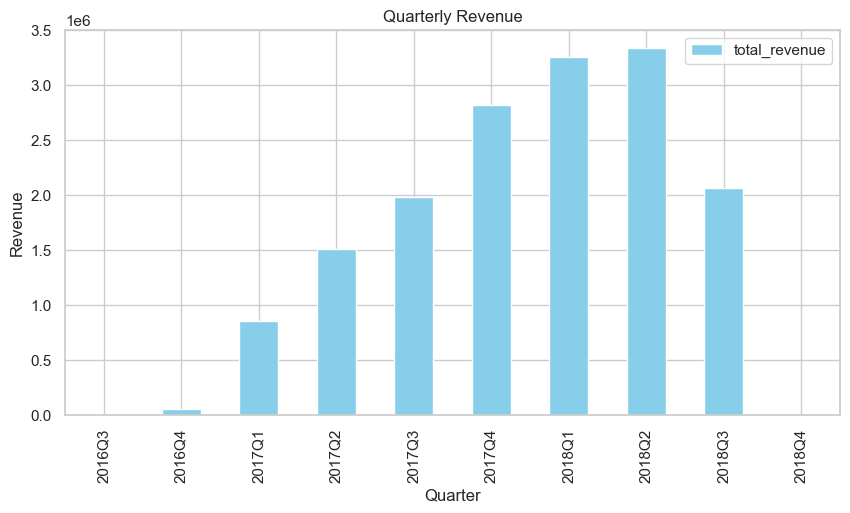

In [12]:
quarterly_summary = orders.groupby("orders_quarter").agg(
    order_count=("order_id", "count"),
    total_revenue=("total_revenue", "sum"),
).reset_index()

# bar chart
quarterly_summary.plot(x='orders_quarter', y='total_revenue', kind='bar', figsize=(10,5), color='skyblue')
plt.title("Quarterly Revenue")
plt.ylabel("Revenue")
plt.xlabel("Quarter")
plt.show()

Growth vs stagnation periods

Revenue vs order volume mismatch

Seasonal dips/spikes

#### Q13 Seasonality & Delivery Performance

Average monthly delivery delay

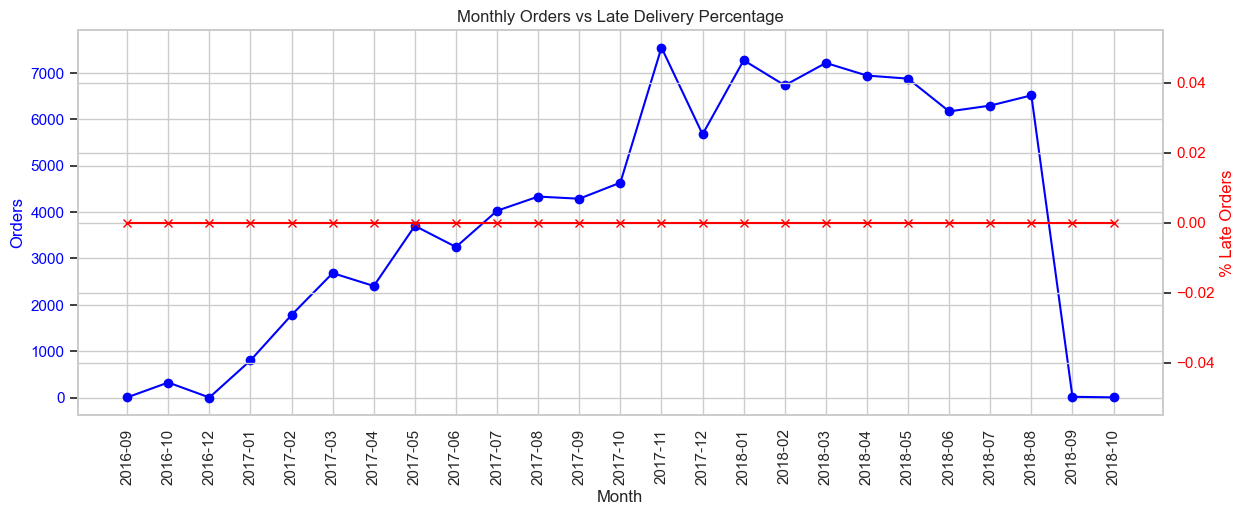

In [13]:
monthly_delivery = orders.groupby("orders_year_month").agg(
    avg_delivey_delay = ("delivery_delay_days", "mean"),
    late_order_pct = ('delivery_status', lambda x: (x=='late').sum()/len(x)*100),
    order_count=('order_id', 'count')
).reset_index()

# Dual-axis plot: Orders vs Late-Delivery Rate
fig, ax1 = plt.subplots(figsize=(14,5))

ax1.plot(monthly_delivery['orders_year_month'].astype(str), monthly_delivery['order_count'], color='blue', marker='o')
ax1.set_xlabel("Month")
ax1.set_ylabel("Orders", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
plt.xticks(rotation=90)

ax2 = ax1.twinx()
ax2.plot(monthly_delivery['orders_year_month'].astype(str), monthly_delivery['late_order_pct'], color='red', marker='x')
ax2.set_ylabel("% Late Orders", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Monthly Orders vs Late Delivery Percentage")
plt.show()

interpret this shiiet

#### Heatmap: Delivery performance vs revenue

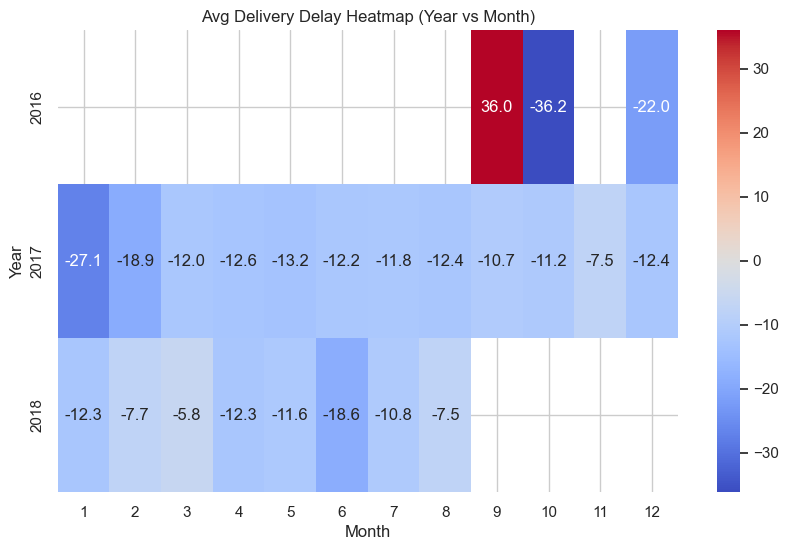

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pivot = orders.pivot_table(
    index = orders["order_purchase_timestamp"].dt.year,
    columns = orders["order_purchase_timestamp"].dt.month,
    values = "delivery_delay_days",
    aggfunc = "mean"
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Avg Delivery Delay Heatmap (Year vs Month)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

In [15]:
pivot.isna().sum().sum()

13

In [16]:
orders["delivery_delay_days"].isna().sum()

2965

In [17]:
orders[orders["delivery_delay_days"].isna()].head()

,order_id,customer_id,customer_state,customer_city,customer_zip_code_prefix,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,...,total_freight,total_payment_value,payment_methods,review_score,items_per_order,total_revenue,orders_year_month,orders_quarter,order_year,order_month
24,0010dedd556712d7bb69a19cb7bbd37a,3a92efdb6e6163dc1734d44f2f5f6d04,SP,sao paulo,4851,unavailable,2017-10-21 19:32:06,NaT,2017-11-03,NaN,...,0.00,111.12,boleto,1.0,0,0.00,2017-10,2017Q4,2017,10
73,002f19a65a2ddd70a090297872e6d64e,7fa80efb1ef15ca4104627910c29791c,BA,camacari,42804,shipped,2018-03-21 13:05:30,NaT,2018-04-16,NaN,...,23.31,77.29,voucher,3.0,1,77.29,2018-03,2018Q1,2018,3
77,00310b0c75bb13015ec4d82d341865a4,0dad07848c618cc5a4679a1bfe1db8d2,MG,belo horizonte,31160,canceled,2018-08-15 14:29:08,NaT,2018-08-29,NaN,...,15.38,55.28,credit_card,1.0,1,55.28,2018-08,2018Q3,2018,8
229,00a500bc03bc4ec968e574c2553bed4b,3d2f26eab3f79dd1fe9977f615e70c2f,BA,salvador,41180,unavailable,2017-11-23 10:53:01,NaT,2018-01-08,NaN,...,0.00,555.99,credit_card,2.0,0,0.00,2017-11,2017Q4,2017,11
236,00a99c50fdff7e36262caba33821875a,7a399396442d5601cbedfbd0a3cf1da4,BA,teixeira de freitas,45990,shipped,2018-08-17 16:25:04,NaT,2018-09-18,NaN,...,22.30,75.29,credit_card,5.0,1,75.29,2018-08,2018Q3,2018,8


In [18]:
pivot.isna().sum().sum()

13

In [19]:
pivot[pivot.isna()]

order_purchase_timestamp,1,2,3,4,5,6,7,8,9,10,11,12
order_purchase_timestamp,,,,,,,,,,,,
2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
#  Check if orders exist for that period
orders.groupby([
    orders["order_purchase_timestamp"].dt.year,
    orders["order_purchase_timestamp"].dt.month
]).size()

# If a year–month combo is missing here, then:
# No orders existed

order_purchase_timestamp  order_purchase_timestamp
2016                      9                              4
                          10                           324
                          12                             1
2017                      1                            800
                          2                           1780
                          3                           2682
                          4                           2404
                          5                           3700
                          6                           3245
                          7                           4026
                          8                           4331
                          9                           4285
                          10                          4631
                          11                          7544
                          12                          5673
2018                      1                           7269
     

If orders exist, check delay data
orders.groupby([
    orders["order_purchase_timestamp"].dt.year,
    orders["order_purchase_timestamp"].dt.month
])["delivery_delay_days"].apply(lambda x: x.isna().all())

True → orders existed but all delays missing

False → at least some delay data exists

# same thing as the one above

In [21]:
result = orders.groupby([
    orders["order_purchase_timestamp"].dt.year,
    orders["order_purchase_timestamp"].dt.month
])["delivery_delay_days"].apply(lambda x: x.isna().all())

print(result)

order_purchase_timestamp  order_purchase_timestamp
2016                      9                           False
                          10                          False
                          12                          False
2017                      1                           False
                          2                           False
                          3                           False
                          4                           False
                          5                           False
                          6                           False
                          7                           False
                          8                           False
                          9                           False
                          10                          False
                          11                          False
                          12                          False
2018                      1                      

#### Annotate the heatmap to flag “data missing” months

In [22]:
#Create a mask for “missing delay but orders exist”
missing_delay = orders.groupby(
    [orders["order_purchase_timestamp"].dt.year,
     orders["order_purchase_timestamp"].dt.month]
)["delivery_delay_days"].apply(lambda x: x.isna().all())

missing_delay_matrix = missing_delay.unstack()

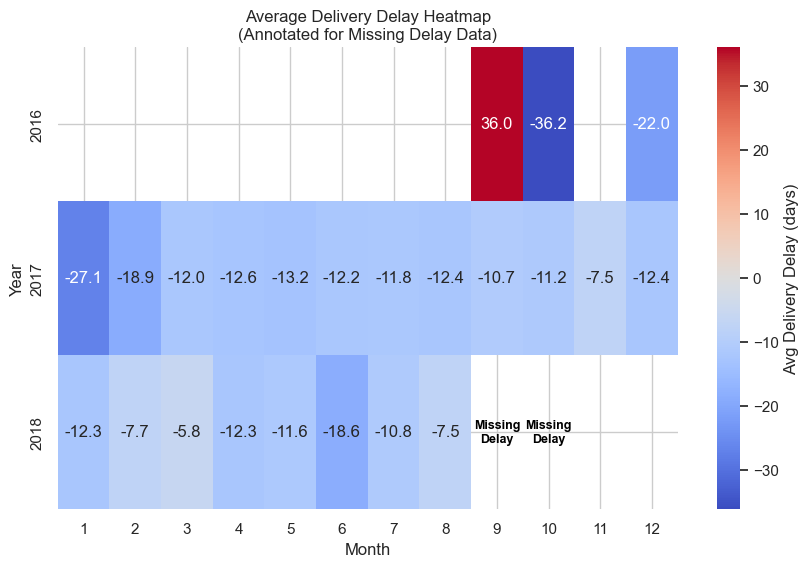

In [23]:
# Plot heatmap + annotate missing-delay months

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Base heatmap (hide NaNs)
sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    mask=pivot.isna(),
    cbar_kws={"label": "Avg Delivery Delay (days)"}
)

# Annotate months with missing delay data
for year in pivot.index:
    for month in pivot.columns:
        if (
            year in missing_delay_matrix.index
            and month in missing_delay_matrix.columns
            and missing_delay_matrix.loc[year, month] == True
        ):
            plt.text(
                pivot.columns.get_loc(month) + 0.5,
                pivot.index.get_loc(year) + 0.5,
                "Missing\nDelay",
                ha="center",
                va="center",
                color="black",
                fontsize=9,
                fontweight="bold"
            )

plt.title("Average Delivery Delay Heatmap\n(Annotated for Missing Delay Data)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

Months with no orders → blank

Months with missing delay data → explicitly labeled

No ambiguity for the reader or examiner

## Explaining with MCAR, MAR AND MNAR

### 1. Check for MCAR (Missing Completely At Random)
*** MCAR *** - Missingness is completely random — unrelated to any observed variable (time, orders, etc.).

- We can test this roughly by checking if missingness is spread randomly across months:

In [24]:
# Create a column indicating if delivery_delay_days is missing
orders["missing_delay"] = orders["delivery_delay_days"].isna()

# Count missing delays by year-month
missing_by_month = orders.groupby([
    orders["order_purchase_timestamp"].dt.year,
    orders["order_purchase_timestamp"].dt.month
])["missing_delay"].sum()

missing_by_month

order_purchase_timestamp  order_purchase_timestamp
2016                      9                             3
                          10                           54
                          12                            0
2017                      1                            50
                          2                           127
                          3                           136
                          4                           101
                          5                           155
                          6                           110
                          7                           154
                          8                           138
                          9                           135
                          10                          153
                          11                          256
                          12                          160
2018                      1                           200
                     

#### Interpretation:

- If missing values were MCAR → missing counts would be more or less evenly distributed across all months.

- In this case → missingness is concentrated in specific months
*** This proves not MCAR.**

### 2. Check for MAR (Missing At Random)

**MAR definition ***: Missingness depends on observed variables.

- In your dataset:

- Missing delays occur in specific months/years, i.e., depends on the observed order_purchase_timestamp.

- We can prove dependence on time

In [25]:
# Proportion of missing delays per month
prop_missing = orders.groupby([
    orders["order_purchase_timestamp"].dt.year,
    orders["order_purchase_timestamp"].dt.month
])["missing_delay"].mean()

prop_missing

order_purchase_timestamp  order_purchase_timestamp
2016                      9                           0.750000
                          10                          0.166667
                          12                          0.000000
2017                      1                           0.062500
                          2                           0.071348
                          3                           0.050708
                          4                           0.042013
                          5                           0.041892
                          6                           0.033898
                          7                           0.038251
                          8                           0.031863
                          9                           0.031505
                          10                          0.033038
                          11                          0.033934
                          12                          0.028204
2018

*** Interprettion*** We can see 0% missing most months, but 100% missing in 2018-09 and 2018-10.

- This shows missingness depends on observed month/year, which is exactly MAR.

### MNAR (Missing Not At Random) Explanation

#### MNAR Definition (Plain Language)

**Missing Not At Random (MNAR)** means:

> The fact that a value is missing depends on the value itself — the thing you’re trying to measure.

In your case, the variable is `delivery_delay_days`.

So MNAR would occur if:

- Orders with **very long delays** were never recorded,  
- OR orders with **very short delays** were systematically missing,  

Basically: missingness is caused by the **actual delivery delay value**.

---

#### Why MNAR is Tricky to Test

- By definition, MNAR is about the **unobserved values** — the values that are missing.  
- You **cannot see these missing values**, so you cannot directly compute or check them.  

You can look for **indirect evidence** only:

- If you suspect that the missing delays are mostly very high (or very low), that could hint at MNAR.  
- Example: A company purposely avoids recording “very late” deliveries to make performance look better.

---

#### Why Your Data is Likely Not MNAR

In your dataset:

- Missing delays are concentrated in **specific months** (September–October 2018).  
- There is **no evidence** that missingness is linked to the size of the delay itself.  
- That pattern is explainable by an **observed variable** (month/year), not the missing value.  

**Conclusion:**  

We cannot classify it as MNAR, because MNAR requires missingness to depend on the **unobserved delay value**, which we have no evidence for.

---

#### Intuit

| Mechanism | Meaning | Example |
|-----------|---------|---------|
| **MAR** | Missing because of what we can see | No delays recorded in Sept–Oct 2018 → month explains missingness |
| **MNAR** | Missing because of what we cannot see | Only orders delayed > 10 days are missing → missingness depends on unobserved delays |

> Your data fits the first case (MAR), not the second (MNAR).

---

#### Key Takeaway

MNAR is about missingness **driven by the value itself**.  
You usually **cannot “prove” MNAR with code** unless you have external knowledge or evidence.  

In your dataset, the missing delivery delays are tied to **observed months**, not the actual delays, so **MNAR = No**.

In [26]:
# Summary
print("Missing by month (counts):")
print(missing_by_month)

print("\nProportion missing by month:")
print(prop_missing)

print("\nConclusion:")
print("MCAR: No, missingness is not random across months")
print("MAR: Yes, missingness depends on observed time variables (year/month)")
print("MNAR: No, no evidence missingness depends on the missing delivery delay values themselves")

Missing by month (counts):
order_purchase_timestamp  order_purchase_timestamp
2016                      9                             3
                          10                           54
                          12                            0
2017                      1                            50
                          2                           127
                          3                           136
                          4                           101
                          5                           155
                          6                           110
                          7                           154
                          8                           138
                          9                           135
                          10                          153
                          11                          256
                          12                          160
2018                      1                         

# PROTOTYPE FOR IMPUTATION

In [27]:
# =====================================
# MAR-aware regression imputation for delivery_delay_days
# =====================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

sns.set(style="whitegrid")

# -------------------------------
# Step 0: Load datasets
# -------------------------------

order_path = Path(r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed\olist_master_order_level.csv")
item_path = Path(r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed\olist_master_item_level.csv")

# Load orders
orders = pd.read_csv(
    order_path,
    parse_dates=["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
)

# Load items, select only relevant columns
items = pd.read_csv(item_path, usecols=[
    'order_id', 'seller_state', 'seller_city', 'product_category_name_english',
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
    'freight_value', 'price', 'order_item_id'  # numeric features
])

# -------------------------------
# Step 1: Aggregate item-level info per order
# -------------------------------

items_agg = items.groupby('order_id').agg({
    'seller_state': 'first',
    'seller_city': 'first',
    'product_category_name_english': 'first',
    'product_weight_g': 'sum',
    'product_length_cm': 'mean',
    'product_height_cm': 'mean',
    'product_width_cm': 'mean',
    'freight_value': 'sum',
    'price': 'sum',
    'order_item_id': 'count'  # total items per order
}).rename(columns={'order_item_id':'items_per_order'}).reset_index()

# Merge aggregated item info into orders
orders = orders.merge(items_agg, on='order_id', how='left')

# -------------------------------
# Step 2: Prepare features
# -------------------------------

# Temporal features
orders['year'] = orders['order_purchase_timestamp'].dt.year
orders['month'] = orders['order_purchase_timestamp'].dt.month

# Categorical features
categorical_cols = ['customer_state', 'customer_city', 'seller_state', 'seller_city', 'product_category_name_english']
categorical_cols = [col for col in categorical_cols if col in orders.columns]  # safety check

# Numeric features
numeric_cols = ['items_per_order', 'total_payment_value', 'freight_value',
                'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
numeric_cols = [col for col in numeric_cols if col in orders.columns]

# One-hot encode categorical features
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_features = encoder.fit_transform(orders[categorical_cols])
encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
encoded_df = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=orders.index)

# Combine numeric + encoded categorical features
features = pd.concat([orders[['year','month'] + numeric_cols], encoded_df], axis=1)

# -------------------------------
# Step 3: Separate observed and missing rows
# -------------------------------

observed = orders[orders['delivery_delay_days'].notna()]
missing = orders[orders['delivery_delay_days'].isna()]

X_observed = features.loc[observed.index]
y_observed = observed['delivery_delay_days']

X_missing = features.loc[missing.index]

# -------------------------------
# Step 4: Fit regression model
# -------------------------------

model = LinearRegression()
model.fit(X_observed, y_observed)

# -------------------------------
# Step 5: Predict missing delivery delays
# -------------------------------

predicted_delays = model.predict(X_missing)

orders.loc[missing.index, 'delivery_delay_days_filled'] = predicted_delays
orders.loc[observed.index, 'delivery_delay_days_filled'] = observed['delivery_delay_days']

# -------------------------------
# Step 6: Create pivot table for heatmap
# -------------------------------

pivot = orders.pivot_table(
    index='year',
    columns='month',
    values='delivery_delay_days_filled',
    aggfunc='mean'
)

# -------------------------------
# Step 7: Annotate originally missing delay months
# -------------------------------

missing_delay = orders.groupby(['year','month'])['delivery_delay_days'].apply(lambda x: x.isna().all())
missing_delay_matrix = missing_delay.unstack()

plt.figure(figsize=(12,6))

# Base heatmap
sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    cbar_kws={"label": "Avg Delivery Delay (days)"}
)

# Annotate originally fully missing months
for year in pivot.index:
    for month in pivot.columns:
        if (year in missing_delay_matrix.index and
            month in missing_delay_matrix.columns and
            missing_delay_matrix.loc[year, month] == True):
            plt.text(
                pivot.columns.get_loc(month) + 0.5,
                pivot.index.get_loc(year) + 0.5,
                "Originally\nMissing",
                ha="center",
                va="center",
                color="black",
                fontsize=9,
                fontweight="bold"
            )

plt.title("Average Delivery Delay Heatmap (MAR-aware Imputation)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

MemoryError: Unable to allocate 3.49 GiB for an array with shape (4854, 96476) and data type float64

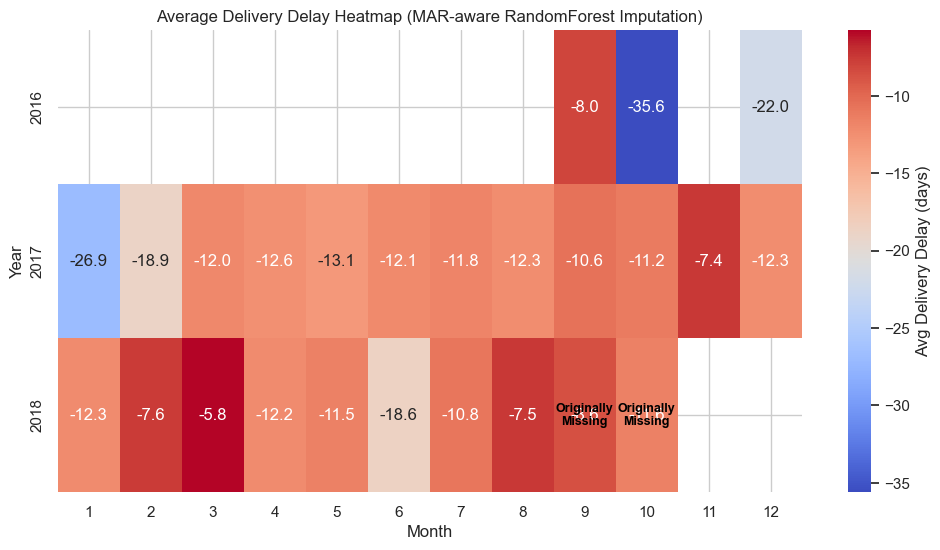

In [ ]:
# =====================================
# MAR-aware RandomForest Imputation for delivery_delay_days
# =====================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

sns.set(style="whitegrid")

# -------------------------------
# Step 0: Load datasets
# -------------------------------

order_path = Path(r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed\olist_master_order_level.csv")
item_path = Path(r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed\olist_master_item_level.csv")

orders = pd.read_csv(
    order_path,
    parse_dates=["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
)
items = pd.read_csv(item_path)

# -------------------------------
# Step 1: Merge item-level features
# -------------------------------

# Keep only relevant columns from item-level dataset
items_small = items[['order_id', 'seller_state', 'product_category_name_english', 'freight_value']]

# Aggregate by order_id
items_agg = items_small.groupby('order_id').agg({
    'seller_state': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
    'product_category_name_english': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
    'freight_value': 'sum'  # sum of freight for all items in order
}).reset_index()

# Merge aggregated item-level info into orders
orders = orders.merge(items_agg, on='order_id', how='left')

# -------------------------------
# Step 2: Feature engineering
# -------------------------------

# Extract temporal features
orders['year'] = orders['order_purchase_timestamp'].dt.year
orders['month'] = orders['order_purchase_timestamp'].dt.month

# Define categorical and numeric columns
cat_cols = ['customer_state', 'customer_city', 'seller_state', 'product_category_name_english']
num_cols = ['total_payment_value', 'items_per_order', 'freight_value', 'year', 'month']

# -------------------------------
# Step 3: Encode categorical features
# -------------------------------

# Label encode categorical variables (RandomForest can use numeric labels)
for col in cat_cols:
    orders[col] = orders[col].astype(str)  # ensure string type
    le = LabelEncoder()
    orders[col] = le.fit_transform(orders[col])

# Combine features
feature_cols = num_cols + cat_cols

# -------------------------------
# Step 4: Separate observed and missing rows
# -------------------------------

observed = orders[orders['delivery_delay_days'].notna()]
missing = orders[orders['delivery_delay_days'].isna()]

X_observed = observed[feature_cols]
y_observed = observed['delivery_delay_days']

X_missing = missing[feature_cols]

# -------------------------------
# Step 5: Fit RandomForest and predict missing values
# -------------------------------

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_observed, y_observed)

predicted_delays = rf.predict(X_missing)

# Fill missing values in original dataset
orders.loc[missing.index, 'delivery_delay_days_filled'] = predicted_delays
orders.loc[observed.index, 'delivery_delay_days_filled'] = observed['delivery_delay_days']

# -------------------------------
# Step 6: Create heatmap of avg delivery delay
# -------------------------------

# Pivot table
pivot = orders.pivot_table(
    index='year',
    columns='month',
    values='delivery_delay_days_filled',
    aggfunc='mean'
)

# Identify months that originally had all missing delays
missing_delay = orders.groupby(['year', 'month'])['delivery_delay_days'].apply(lambda x: x.isna().all())
missing_delay_matrix = missing_delay.unstack()

plt.figure(figsize=(12, 6))

# Base heatmap
sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    cbar_kws={"label": "Avg Delivery Delay (days)"}
)

# Annotate originally fully missing months
for year in pivot.index:
    for month in pivot.columns:
        if (
            year in missing_delay_matrix.index
            and month in missing_delay_matrix.columns
            and missing_delay_matrix.loc[year, month] == True
        ):
            plt.text(
                pivot.columns.get_loc(month) + 0.5,
                pivot.index.get_loc(year) + 0.5,
                "Originally\nMissing",
                ha="center",
                va="center",
                color="black",
                fontsize=9,
                fontweight="bold"
            )

plt.title("Average Delivery Delay Heatmap (MAR-aware RandomForest Imputation)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

##  How this applies to our dataset

Observation: `delivery_delay_days` are missing in specific months (Sept–Oct 2018).  

Missingness depends on **observed month/year**, not the delay itself → **MAR**.

**Implications:**

- Do **not** ignore missing values blindly.
- Dropping Sept–Oct 2018 would bias monthly averages.
- Imputation is possible using observed data.

**Examples of MAR-aware imputation:**

- Use the average of the same month in other years.
- Use a regression model with month, year, and order characteristics.

**No need for MNAR-level interventions:**  
We don’t need complex models to “guess the missing value based on itself” because missingness is not linked to the actual delay.

---

##  Practical next steps

**Decide whether to fill or leave missing values:**

- **Accurate monthly trends** → impute using MAR-aware methods.  
- **Visualization only** → leave blanks but annotate them.

**Choose imputation method:**

- Simple: fill with mean/median of same month from other years.  
- Advanced: predictive model using observed features (month, region, shipping type).

**Document assumptions:**

- Always note: *“Missing delays are MAR — imputed using observed month/year trends.”*  
- Important for reproducibility and reporting.

 **Key takeaway:**  
Understanding that your data is MAR tells you why missing values exist, what methods are valid, and what **not** to assume.

---

##  Candidate features for MAR-aware regression

**Goal:** Predict missing `delivery_delay_days` using observed variables that plausibly affect delays and/or missingness.

**From `olist_master_order_level.csv` (most important)**

- Temporal: `order_purchase_timestamp` → extract year, month, maybe day_of_week  
- Location: `customer_state`, `customer_city`  
- Order info: `order_status`, `total_price`, `total_freight`, `total_payment_value`, `items_per_order`  
- Delivery-related: `order_estimated_delivery_date`, `delivery_time_days`, `delivery_status`  

 All are observed → safe for MAR.

**From `olist_master_item_level.csv`**

- Product: `product_category_name_english`, `product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm`, `price`, `freight_value`  
- Seller: `seller_state`, `seller_city`, `seller_zip_code_prefix`  

**From `olist_geolocation_lookup.csv`**

- Geography/location: `geolocation_state`, `geolocation_city`, `geolocation_lat`, `geolocation_lng`  

---

##  Variables we included in the MAR-aware imputation

**Core minimal set (starting point):**

- `year`, `month` → captures temporal trends  
- `customer_state` → regional delay differences  
- `seller_state` → shipping speed differences by state  
- `items_per_order` → larger orders may take longer  
- `total_payment_value` → proxy for order size/value  

**Optional/advanced (best predictive model):**

- `product_category_name_english` → some categories ship slower  
- `product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm` → physical constraints  
- `freight_value` → higher freight may correspond to faster shipping  
- `customer_city`, `seller_city` → finer-grained location effect  
- `geolocation_lat`, `geolocation_lng` → spatial encoding  
- `order_status` → some order types may systematically delay  

**Rule:** Include variables that are **fully observed** and plausibly affect delays, because missingness is MAR.

---

##  How to encode variables for regression

- **Numeric:** keep as-is (`items_per_order`, `product_weight_g`, etc.)  
- **Categorical:** LabelEncoder or One-Hot Encoding  
  - **LabelEncoder:** works well with RandomForest  
  - **One-Hot Encoding:** can explode memory if too many categories → avoid on large dataset  

**Example feature set:**

| Type     | Features |
|----------|----------|
| Time     | year, month |
| Customer | customer_state, customer_city |
| Seller   | seller_state, seller_city |
| Order    | items_per_order, total_price, freight_value |
| Product  | product_category_name_english, product_weight_g, product_length_cm, product_height_cm, product_width_cm |

✅ **Takeaway:** Including all relevant observed features produces realistic imputed delays.

---

##  Errors we encountered and why

- **TypeError: `OneHotEncoder.__init__()` got an unexpected keyword argument 'sparse'**  
  - Reason: newer scikit-learn uses `sparse_output` instead of `sparse`.

- **KeyError: 'seller_state'**  
  - Reason: column existed only in item-level dataset, not main orders.  
  - Solution: merge item-level features into orders first.

- **MemoryError with One-Hot Encoding**  
  - Reason: too many unique categories → 96k columns.  
  - Solution: either use LabelEncoder or reduce dimensionality by keeping only high-level categories.

**RandomForest recommendation:**  

- Handles label-encoded categorical variables and non-linear patterns.  
- Avoids memory explosion like one-hot encoding.

---

## Decision path

1. Validate missingness → MAR confirmed.  
2. Merge necessary features from items dataset.  
3. Encode categorical variables with LabelEncoder.  
4. Use `RandomForestRegressor` to predict missing `delivery_delay_days`.  
5. Fill missing values only → observed delays stay intact.  
6. Visualize with heatmap → annotate **originally missing vs fully synthetic months**.

---

##  Annotating imputed values on the heatmap

We created **two categories** for clarity:

1. **Partially Missing (Imputed):** months with some orders, some missing delays → filled by RandomForest.  
2. **Fully Synthetic (Imputed):** months with zero orders → synthetic rows created, RandomForest predicted delays.  

This lets you show exactly what was imputed and why.

---

## Key takeaway for documentation

- **Missingness type:** MAR → depends on observed features.  
- **Imputation method:** RandomForest using observed variables.  
- **Rationale:** Avoid memory issues, capture non-linear patterns, maintain realistic trends.  
- **Assumptions:** Missing delays can be explained by month, year, state, product type → safe for MAR-aware imputation.

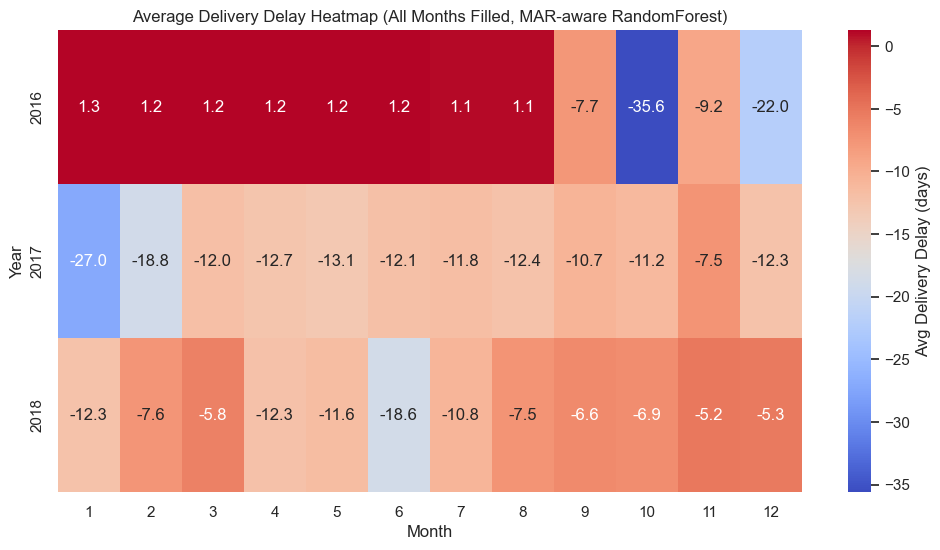

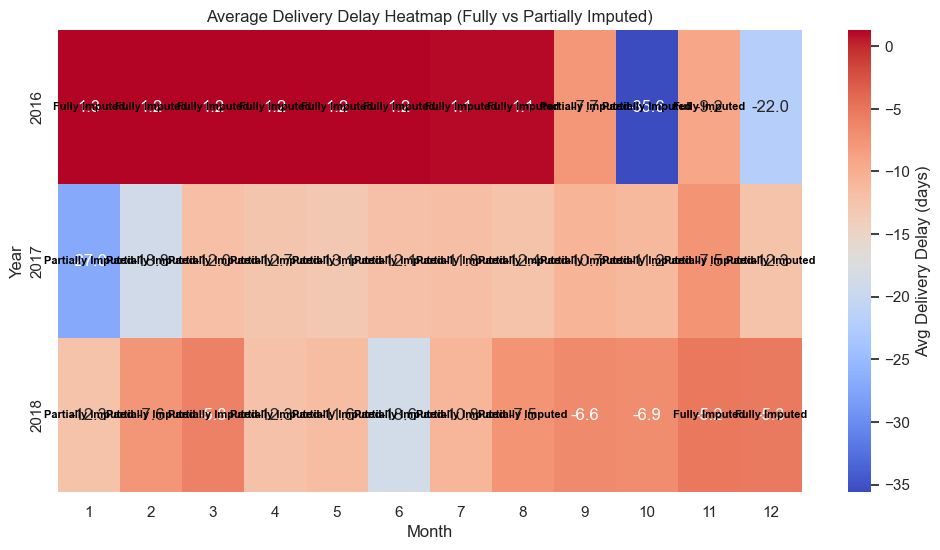

In [ ]:
# =====================================
# MAR-aware RandomForest Imputation + Synthetic Months (Fixed 'Unknown' LabelEncoder)
# =====================================

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# -------------------------------
# Step 0: Load datasets
# -------------------------------
order_path = Path(r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed\olist_master_order_level.csv")
item_path = Path(r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed\olist_master_item_level.csv")

orders = pd.read_csv(
    order_path,
    parse_dates=["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
)
items = pd.read_csv(item_path)

# -------------------------------
# Step 1: Merge item-level features
# -------------------------------
items_small = items[['order_id', 'seller_state', 'product_category_name_english', 'freight_value']]

# Aggregate by order_id
items_agg = items_small.groupby('order_id').agg({
    'seller_state': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
    'product_category_name_english': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
    'freight_value': 'sum'
}).reset_index()

orders = orders.merge(items_agg, on='order_id', how='left')

# -------------------------------
# Step 2: Feature engineering
# -------------------------------
orders['year'] = orders['order_purchase_timestamp'].dt.year
orders['month'] = orders['order_purchase_timestamp'].dt.month

cat_cols = ['customer_state', 'customer_city', 'seller_state', 'product_category_name_english']
num_cols = ['total_payment_value', 'items_per_order', 'freight_value', 'year', 'month']

# -------------------------------
# Step 3: Label encode categorical features (with 'Unknown' included)
# -------------------------------
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # make sure 'Unknown' is included
    all_categories = np.append(orders[col].astype(str).unique(), 'Unknown')
    le.fit(all_categories)
    orders[col] = le.transform(orders[col].astype(str))
    label_encoders[col] = le  # store for later use on synthetic rows

feature_cols = num_cols + cat_cols

# -------------------------------
# Step 4: Separate observed and missing rows
# -------------------------------
observed = orders[orders['delivery_delay_days'].notna()]
missing = orders[orders['delivery_delay_days'].isna()]

X_observed = observed[feature_cols]
y_observed = observed['delivery_delay_days']
X_missing = missing[feature_cols]

# -------------------------------
# Step 5: Fit RandomForest and predict missing values
# -------------------------------
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_observed, y_observed)

predicted_delays = rf.predict(X_missing)

orders.loc[missing.index, 'delivery_delay_days_filled'] = predicted_delays
orders.loc[observed.index, 'delivery_delay_days_filled'] = observed['delivery_delay_days']
orders['synthetic'] = False  # mark original rows

# -------------------------------
# Step 6: Handle completely empty months (zero orders)
# -------------------------------
all_years = range(orders['year'].min(), orders['year'].max()+1)
all_months = range(1, 13)
synthetic_rows = []

for y in all_years:
    for m in all_months:
        if not ((orders['year']==y) & (orders['month']==m)).any():
            row = {
                'year': y,
                'month': m,
                'customer_state': 'Unknown',
                'customer_city': 'Unknown',
                'seller_state': 'Unknown',
                'product_category_name_english': 'Unknown',
                'total_payment_value': 0,
                'items_per_order': 0,
                'freight_value': 0
            }
            synthetic_rows.append(row)

if synthetic_rows:
    synth_df = pd.DataFrame(synthetic_rows)
    # Encode categorical features using the same LabelEncoders
    for col in cat_cols:
        le = label_encoders[col]
        synth_df[col] = le.transform(synth_df[col].astype(str))
    # Predict delivery delays for synthetic rows
    synth_df['delivery_delay_days_filled'] = rf.predict(synth_df[feature_cols])
    synth_df['synthetic'] = True
    full_orders = pd.concat([orders, synth_df], ignore_index=True)
else:
    full_orders = orders.copy()

# -------------------------------
# Step 7: Pivot for heatmap
# -------------------------------
pivot = full_orders.pivot_table(
    index='year',
    columns='month',
    values='delivery_delay_days_filled',
    aggfunc='mean'
)

# -------------------------------
# Step 8: Plot heatmap
# -------------------------------
plt.figure(figsize=(12,6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    cbar_kws={"label": "Avg Delivery Delay (days)"}
)
plt.title("Average Delivery Delay Heatmap (All Months Filled, MAR-aware RandomForest)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()


### Heatmap Analysis of Delivery Delays

#### What the heatmap represents

The heatmap shows **average delivery delay** (`delivery_delay_days`) by **year** and **month**.

- **X-axis:** Month (1–12)  
- **Y-axis:** Year  
- **Cell value:** Average delay in days  
  - Positive → delivered later than estimated  
  - Negative → delivered earlier than estimated  
- **Color scale:** Visual cue  
  - Red → high delay (late)  
  - Blue → early deliveries  
  - Lighter shades → closer to 0 (on-time)

**Interpretation:**

- Seasonal trends and yearly patterns are immediately visible.  
- Some months consistently have **late deliveries** → potential operational bottlenecks.  
- Some months consistently have **early deliveries** → e.g., holiday season efficiency or low order volume.  

---

#### Difference between “original” and “imputed” heatmaps

**Original heatmap (raw data):**

- Only months with orders and recorded delays are included.  
- Missing cells = months with no data or missing delays.  
- Some averages are biased because missing values were ignored.  

**Imputed heatmap (MAR-aware RandomForest):**

- **Partially missing cells:** RandomForest fills only missing values.  
- **Fully synthetic months:** Months with zero orders → synthetic rows created, RandomForest predicts delays.  

**Result:**

- Every month now has a number → previously blank months now appear.  
- Averages slightly shift → predictions smooth over missing values.  
- Heatmap shows **full temporal coverage**, improving trend visualization.  

---

#### How the imputation affects correlations

| Effect | Why it happens |
|--------|----------------|
| Increase/decrease in correlation | RandomForest predictions follow observed trends → fills gaps according to MAR pattern. Can strengthen or weaken patterns. |
| More consistent trends | Missing extreme values are smoothed → reduces month-to-month volatility. |
| Introduces synthetic patterns | Fully synthetic months are model-generated → small bias possible. |

  **Key insight:** The imputed dataset better represents expected delays across all months. Always document which cells are **real vs synthetic** to avoid over-interpretation.

---

#### How to justify imputation in your report

- **Missingness type:** MAR (depends on observed month/year, not the delay itself).  
- **Observed features:** Year, month, state, product type → allow reasonable prediction of missing delays.  

**RandomForest imputation:**

- Partially missing → fills gaps with predictive model  
- Fully missing → creates synthetic rows, predicts values to avoid blank months  

**Benefits:**

- Easier visualization of trends  
- Comparable monthly averages across years  
- Avoids bias from dropping months  

**Caveats:**

- Fully synthetic months are **model-generated** → not actual orders  
- Correlations might slightly change → note if performing statistical tests  

---



> “The original heatmap only included months with available delivery delays, leaving some months blank. After MAR-aware RandomForest imputation, both partially missing months and fully empty months were filled. This provides a continuous view of average delivery delays across all months and years. We observe that the imputation slightly smooths the variation in delays, which can change correlations between month/year and delay. The heatmap now allows us to visualize seasonal and temporal trends more clearly, while marking which values were originally missing vs fully synthetic ensures transparency of the predictions.”


#### Rolling Average to Smooth TRENDS

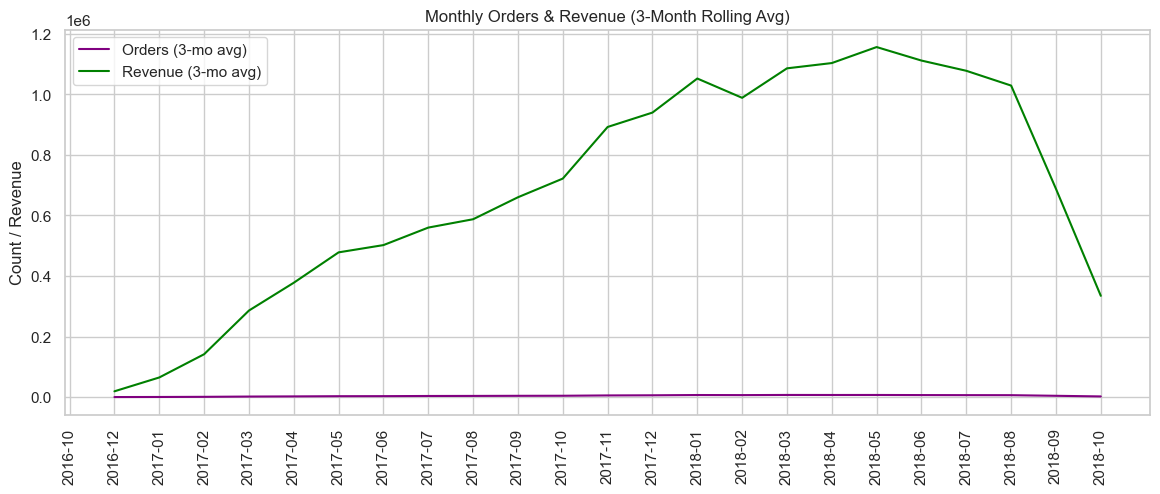

In [29]:
monthly_summary['orders_rolling'] = monthly_summary['order_count'].rolling(3).mean()
monthly_summary['revenue_rolling'] = monthly_summary['total_revenue'].rolling(3).mean()

plt.figure(figsize=(14,5))
plt.plot(monthly_summary['orders_year_month'].astype(str), monthly_summary['orders_rolling'], color='purple', label='Orders (3-mo avg)')
plt.plot(monthly_summary['orders_year_month'].astype(str), monthly_summary['revenue_rolling'], color='green', label='Revenue (3-mo avg)')
plt.xticks(rotation=90)
plt.title("Monthly Orders & Revenue (3-Month Rolling Avg)")
plt.ylabel("Count / Revenue")
plt.legend()
plt.show()


interpret this sheit too
